# YOLO11-seg vs RF-DETR-Seg vs both together — Red Sea landings

Two models are trained on the same data and scored the same way, and a third system combines them.

| | Strength | Weakness |
|---|---|---|
| **YOLO11-seg** | high input resolution (1024+), fast, fine detail | NMS can delete one of two fish lying side by side |
| **RF-DETR-Seg** | no NMS, strong pretrained transformer backbone → crowded trays, new contexts, little data | low native input resolution → coarse on a full tray (handled here with tiled passes) |
| **Ensemble** | a fish both models find is almost never a false alarm; where their outlines disagree, the image colours decide | slowest |

| § | What |
|---|---|
| 2 | Lighting + rotation augmentation written to disk (used by both models) |
| 3 | Train YOLO11-seg · build a COCO copy of the data · train RF-DETR-Seg |
| 4 | Robust inference, tiles, ensemble, boundary refinement |
| 5 | Length from the outline + reliability flags |
| 6 | Segmentation benchmark for every system: mIoU, Dice, boundary F, outline error — isolated vs touching fish, by lighting |
| 7 | Lighting stress test for every system |
| 8 | **Prediction vs ground truth** (22 hand-measured fish, table built in) for every system |
| 9 | Run on any folder · 10 numbers to report |

**Before running:** Internet **On**, GPU **T4**. Add your dataset (`fish` + `marker`) and the tray photo.
Training both models takes a while — you can train one per session: set the other `TRAIN_…` to
`False` and point its `…_WEIGHTS` at the saved file.

## 0. Settings — the only cell you should need to edit

In [1]:
MODELS       = ["yolo", "rfdetr"]   # which models to use. With both, an "ensemble" is evaluated too
FINAL_MODEL  = "ensemble"           # system used for the numbered overlay / MAPPING (sec. 8) and sec. 9

# ---- YOLO ------------------------------------------------------------------
TRAIN_YOLO    = True
YOLO_WEIGHTS  = None                # path to a trained .pt when TRAIN_YOLO = False (None = search /kaggle/input)
BASE_WEIGHTS  = "yolo11m-seg.pt"    # out of memory? "yolo11s-seg.pt", or lower BATCH / IMGSZ
IMGSZ, EPOCHS, BATCH = 1024, 150, 4

# ---- RF-DETR ---------------------------------------------------------------
TRAIN_RFDETR   = True
RFDETR_WEIGHTS = None               # path to checkpoint_best_total.pth when TRAIN_RFDETR = False
RF_MODEL       = "RFDETRSegMedium"  # RFDETRSegNano / Small / Medium / Large ...
RF_EPOCHS, RF_BATCH, RF_ACCUM, RF_LR = 50, 2, 8, 1e-4
RF_TILES       = True               # also run RF-DETR on 9 overlapping half-size tiles (its input resolution is low)

# ---- shared ----------------------------------------------------------------
AUG_COPIES      = 2                 # augmented copies per training image (lighting + 90-degree rotation)
CONF            = 0.25
NMS_IOU         = 0.70              # YOLO only; high on purpose for fish lying side by side
SCALES          = (1024, 1280)      # YOLO image sizes in robust mode
USE_CLAHE_PASS  = True              # extra pass on a contrast-normalised copy
USE_GRABCUT     = True              # boundary refinement
USE_SAM         = False
SOLO_CONF       = 0.40              # ensemble: a fish found by only ONE model must be at least this confident
WORK_MAX        = 2000
MIN_AREA_FRAC   = 0.0004

# ---- scale -----------------------------------------------------------------
MARKER_CM     = 30.0                # real length of the `marker` object  <-- CHECK THIS
MARKER_MIN_PX = 250
MANUAL_RULER  = None                # or (x0, y0, x1, y1, cm) in original-image pixels

# ---- ground-truth test (section 8) ----------------------------------------
GT_IMAGE = None                     # "/kaggle/input/<dataset>/<photo>"; None = search for gt_test.*
MAPPING  = {}                       # {detection_number: fish_id} from the numbered overlay of FINAL_MODEL

SEED = 0

## 1. Setup

In [2]:
!pip install -q -U ultralytics
!pip install -q rfdetr supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 602.7/602.7 kB 15.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 55.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 103.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.3 MB/s eta 0:00:00


In [3]:
import os, io, json, math, shutil, yaml, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2, torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO
warnings.filterwarnings("ignore")
print("CUDA:", torch.cuda.is_available())

HAVE_RF = False
if "rfdetr" in MODELS:
    try:
        import rfdetr; HAVE_RF = True; print("rfdetr", getattr(rfdetr, "__version__", ""))
    except Exception as e:
        print("rfdetr could not be imported - continuing with YOLO only:", e)

WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True, parents=True)
INP  = Path("/kaggle/input")

def find_dataset():
    for y in sorted(INP.rglob("data.yaml")):
        d = yaml.safe_load(open(y)); n = d.get("names", [])
        n = [n[k] for k in sorted(n)] if isinstance(n, dict) else list(n)
        if "fish" in n and (y.parent / "train" / "images").exists():
            return y.parent, n
    return None, None

DS, DS_NAMES = find_dataset()
assert DS is not None, "No dataset with a 'fish' class found under /kaggle/input - click Add Input"
VAL_DIR = DS / "valid" if (DS / "valid").exists() else DS / "val"
print("dataset:", DS); print("classes:", DS_NAMES)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
CUDA: True
rfdetr 
dataset: /kaggle/input/datasets/kingpower1234/asdfg2/aqwdata
classes: ['fish', 'marker']


## 2. Augmentation written to disk

Pixel-level lighting effects that really happen at a landing site (hard shadow, glare on wet skin,
colour cast, dusk), plus a random 90° rotation with the polygons rotated to match. Writing them to
disk means **both** models train on exactly the same images — RF-DETR has no rotation augmentation
of its own, and fish on a tray point every way.

In [4]:
import numpy as np, cv2

def p_gamma(img, g):
    lut = (np.linspace(0, 1, 256) ** g * 255).astype(np.uint8)
    return cv2.LUT(img, lut)

def p_cast(img, bgr):
    return np.clip(img.astype(np.float32) * np.array(bgr, np.float32)[None, None], 0, 255).astype(np.uint8)

def _grid(img):
    h, w = img.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    return h, w, yy, xx

def p_shadow(img, rng, strength=0.40):
    h, w, yy, xx = _grid(img)
    a = rng.uniform(0, np.pi)
    d = (xx - w * rng.uniform(.3, .7)) * np.cos(a) + (yy - h * rng.uniform(.3, .7)) * np.sin(a)
    soft = 1 / (1 + np.exp(-d / (0.03 * max(h, w))))
    gain = strength + (1 - strength) * soft
    return np.clip(img * gain[..., None], 0, 255).astype(np.uint8)

def p_glare(img, rng, n=5):
    h, w, yy, xx = _grid(img)
    out = img.astype(np.float32)
    for _ in range(n):
        cx, cy = rng.uniform(0, w), rng.uniform(0, h)
        s = rng.uniform(.02, .06) * max(h, w)
        out += 220 * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * s * s))[..., None]
    return np.clip(out, 0, 255).astype(np.uint8)

def p_blur(img, k=9):   return cv2.GaussianBlur(img, (k, k), 0)
def p_noise(img, rng, sigma=14):
    return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)
def p_jpeg(img, q=20):
    return cv2.imdecode(cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, q])[1], cv2.IMREAD_COLOR)

# fixed conditions for the stress test (section 7)
STRESS = {
    "original":   lambda im, r: im,
    "dark":       lambda im, r: p_gamma(im, 2.2),
    "very dark":  lambda im, r: p_gamma(p_cast(im, (.45, .45, .45)), 1.6),
    "overexposed":lambda im, r: p_gamma(im, 0.45),
    "warm cast":  lambda im, r: p_cast(im, (0.75, 1.0, 1.25)),
    "blue cast":  lambda im, r: p_cast(im, (1.30, 1.05, 0.75)),
    "shadow":     lambda im, r: p_shadow(im, r, 0.30),
    "glare":      lambda im, r: p_glare(im, r, 6),
    "blur":       lambda im, r: p_blur(im, 11),
    "noise+jpeg": lambda im, r: p_jpeg(p_noise(im, r, 16), 20),
}

def random_photometric(img, rng):
    out = p_gamma(img, float(np.exp(rng.uniform(np.log(0.5), np.log(2.2)))))
    out = p_cast(out, rng.uniform(0.8, 1.2, 3))
    if rng.random() < .40: out = p_shadow(out, rng, rng.uniform(.3, .6))
    if rng.random() < .30: out = p_glare(out, rng, int(rng.integers(2, 6)))
    if rng.random() < .25: out = p_blur(out, int(rng.choice([5, 7, 9])))
    if rng.random() < .25: out = p_noise(out, rng, rng.uniform(5, 14))
    if rng.random() < .25: out = p_jpeg(out, int(rng.integers(20, 60)))
    return out

In [5]:
def rot_image(img, k):
    return img if k == 0 else cv2.rotate(img, {1: cv2.ROTATE_90_CLOCKWISE, 2: cv2.ROTATE_180,
                                               3: cv2.ROTATE_90_COUNTERCLOCKWISE}[k])

def rot_label(text, k):
    """Rotate YOLO polygon labels (normalised coordinates) by k x 90 degrees, matching rot_image."""
    out = []
    for ln in text.strip().splitlines():
        p = ln.split()
        if len(p) < 7: continue
        xy = np.array(p[1:], np.float64).reshape(-1, 2); x, y = xy[:, 0], xy[:, 1]
        if   k == 1: xy = np.stack([1 - y, x], 1)
        elif k == 2: xy = np.stack([1 - x, 1 - y], 1)
        elif k == 3: xy = np.stack([y, 1 - x], 1)
        out.append(p[0] + " " + " ".join(f"{v:.6f}" for v in xy.reshape(-1)))
    return "\n".join(out) + "\n"

wrote 56 augmented training images


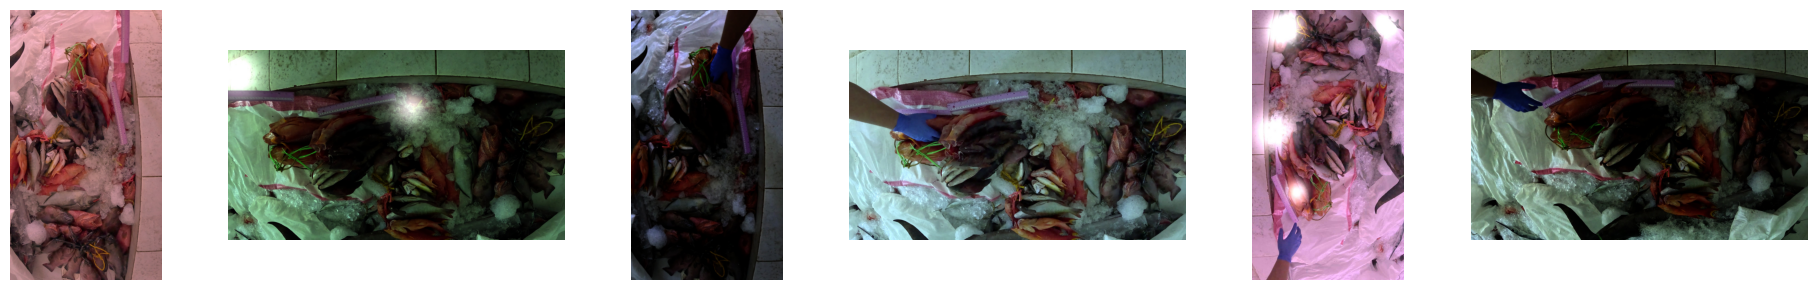

In [6]:
AUG = WORK / "aug"
DO_AUG = AUG_COPIES > 0 and (TRAIN_YOLO or (TRAIN_RFDETR and HAVE_RF))
if DO_AUG:
    shutil.rmtree(AUG, ignore_errors=True)
    (AUG / "images").mkdir(parents=True); (AUG / "labels").mkdir(parents=True)
    rng = np.random.default_rng(SEED); n = 0
    for ip in sorted((DS / "train" / "images").glob("*")):
        lp = DS / "train" / "labels" / (ip.stem + ".txt")
        img = cv2.imread(str(ip))
        if img is None or not lp.exists(): continue
        txt = open(lp).read()
        for c in range(AUG_COPIES):
            k = int(rng.integers(0, 4))
            cv2.imwrite(str(AUG / "images" / f"{ip.stem}_A{c}.jpg"), random_photometric(rot_image(img, k), rng),
                        [cv2.IMWRITE_JPEG_QUALITY, 92])
            open(AUG / "labels" / f"{ip.stem}_A{c}.txt", "w").write(rot_label(txt, k)); n += 1
    print(f"wrote {n} augmented training images")
    show = sorted((AUG / "images").glob("*"))[:6]
    fig, ax = plt.subplots(1, len(show), figsize=(3.2 * len(show), 3))
    for a, p in zip(np.atleast_1d(ax), show):
        a.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)); a.axis("off")
    plt.tight_layout(); plt.show()

## 3a. Train YOLO11-seg

| Setting | Problem it targets |
|---|---|
| `overlap_mask=False` | every fish keeps its own full mask during training — matters when fish lie on each other |
| `mask_ratio=1` | masks supervised at full resolution instead of 1/4 → **sharper boundaries** |
| `copy_paste=0.5` | fish pasted over other fish → many more overlaps/occlusions than you annotated |
| `degrees=180`, flips | any orientation |
| `mosaic`, `scale` | new contexts and sizes; off for the last 20 epochs |
| `hsv_v=0.6` + §2 | illumination |

In [8]:
READY = set()
data_yaml = WORK / "fish_robust.yaml"
train_dirs = [str(DS / "train" / "images")] + ([str(AUG / "images")] if DO_AUG else [])
yaml.safe_dump({"train": train_dirs, "val": str(VAL_DIR / "images"),
                "names": {i: n for i, n in enumerate(DS_NAMES)}}, open(data_yaml, "w"))

if "yolo" in MODELS:
    if TRAIN_YOLO:
        YOLO(BASE_WEIGHTS).train(
            data=str(data_yaml), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, patience=40, cos_lr=True,
            project=str(WORK / "runs"), name="robust_seg", exist_ok=True, seed=SEED, plots=True,
            overlap_mask=False, mask_ratio=1, copy_paste=0.5, copy_paste_mode="flip",
            degrees=180, flipud=0.5, fliplr=0.5, translate=0.1, scale=0.5, shear=2.0, perspective=0.0005,
            mosaic=1.0, close_mosaic=20, mixup=0.0, hsv_h=0.02, hsv_s=0.7, hsv_v=0.6)
        shutil.copy(WORK / "runs" / "robust_seg" / "weights" / "best.pt", WORK / "best_yolo.pt")
        YOLO_WEIGHTS = WORK / "best_yolo.pt"            # top level of /kaggle/working survives the session
    elif YOLO_WEIGHTS is None:
        c = [p for p in INP.rglob("*.pt") if not p.name.startswith("yolo")]
        assert c, "TRAIN_YOLO=False but no trained .pt found under /kaggle/input"
        YOLO_WEIGHTS = sorted(c, key=lambda p: p.stat().st_mtime)[-1]
    seg = YOLO(str(YOLO_WEIGHTS)); NAMES = seg.names
    assert "fish" in NAMES.values(), "these weights have no 'fish' class - wrong file"
    print("YOLO weights:", YOLO_WEIGHTS, NAMES); READY.add("yolo")
    m = seg.val(data=str(data_yaml), imgsz=IMGSZ, split="val", verbose=False, plots=False)
    VAL_SUMMARY = {"yolo_mask_mAP50": float(m.seg.map50), "yolo_mask_mAP50_95": float(m.seg.map)}
    print(VAL_SUMMARY)

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/fish_robust.yaml, degrees=180, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.6, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=1, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=robust_seg, nbs=64, nms=None, opset=None, 

OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 52.81 MiB is free. Including non-PyTorch memory, this process has 14.50 GiB memory in use. Of the allocated memory 14.27 GiB is allocated by PyTorch, and 77.33 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 3b. Build a COCO copy of the data and train RF-DETR-Seg

The COCO files are written here from your YOLO polygons, so class numbering is under our control
(`0 = fish`, `1 = marker`) and the augmented images from §2 are included. Images are linked, not copied.

In [ ]:
def build_coco_split(pairs, out_dir, names):
    """pairs = [(image_path, label_path)]. Writes out_dir/_annotations.coco.json and links the images."""
    out_dir = Path(out_dir); shutil.rmtree(out_dir, ignore_errors=True); out_dir.mkdir(parents=True)
    images, anns = [], []
    for ip, lp in pairs:
        ip, lp = Path(ip), Path(lp)
        if not lp.exists(): continue
        with Image.open(ip) as im: W, H = im.size
        dst = out_dir / ip.name
        try: os.symlink(ip, dst)
        except OSError: shutil.copy(ip, dst)
        iid = len(images); images.append({"id": iid, "file_name": ip.name, "width": W, "height": H})
        for ln in open(lp).read().strip().splitlines():
            p = ln.split()
            if len(p) < 7: continue
            xy = np.array(p[1:], np.float64).reshape(-1, 2) * [W, H]
            xy[:, 0] = xy[:, 0].clip(0, W); xy[:, 1] = xy[:, 1].clip(0, H)
            x0, y0 = xy.min(0); x1, y1 = xy.max(0)
            area = float(cv2.contourArea(xy.astype(np.float32)))
            if area < 4: continue
            anns.append({"id": len(anns), "image_id": iid, "category_id": int(float(p[0])), "iscrowd": 0,
                         "bbox": [float(x0), float(y0), float(x1 - x0), float(y1 - y0)], "area": area,
                         "segmentation": [[round(float(v), 2) for v in xy.reshape(-1)]]})
    cats = [{"id": i, "name": n, "supercategory": "none"} for i, n in enumerate(names)]
    json.dump({"images": images, "annotations": anns, "categories": cats},
              open(out_dir / "_annotations.coco.json", "w"))
    return len(images), len(anns)

In [ ]:
def pairs_of(split_dir):
    return [(p, Path(split_dir) / "labels" / (p.stem + ".txt")) for p in sorted((Path(split_dir) / "images").glob("*"))]

RF_READY = False
if "rfdetr" in MODELS and HAVE_RF:
    RFClass = getattr(rfdetr, RF_MODEL)
    if TRAIN_RFDETR:
        COCO = WORK / "coco"
        tr = pairs_of(DS / "train") + (pairs_of(AUG) if DO_AUG else [])
        print("train", build_coco_split(tr, COCO / "train", DS_NAMES))
        print("valid", build_coco_split(pairs_of(VAL_DIR), COCO / "valid", DS_NAMES))
        te = DS / "test" if (DS / "test" / "images").exists() else VAL_DIR      # rfdetr expects a test folder
        print("test ", build_coco_split(pairs_of(te), COCO / "test", DS_NAMES))
        RFClass().train(dataset_dir=str(COCO), epochs=RF_EPOCHS, batch_size=RF_BATCH,
                        grad_accum_steps=RF_ACCUM, lr=RF_LR, output_dir=str(WORK / "rfdetr_out"))
        ck = sorted((WORK / "rfdetr_out").glob("checkpoint_best_total.pth")) or \
             sorted((WORK / "rfdetr_out").glob("checkpoint_best*.pth"))
        assert ck, "RF-DETR training finished but no best checkpoint was found in rfdetr_out"
        shutil.copy(ck[0], WORK / "best_rfdetr.pth"); RFDETR_WEIGHTS = WORK / "best_rfdetr.pth"
    elif RFDETR_WEIGHTS is None:
        c = sorted(INP.rglob("*rfdetr*.pth")) + sorted(INP.rglob("checkpoint_best*.pth"))
        assert c, "TRAIN_RFDETR=False but no RF-DETR checkpoint (.pth) found under /kaggle/input"
        RFDETR_WEIGHTS = c[0]
    rf = RFClass(pretrain_weights=str(RFDETR_WEIGHTS)); RF_READY = True
    print("RF-DETR weights:", RFDETR_WEIGHTS)

## 4. Robust inference, tiles, ensemble, boundary refinement

**Passes.** YOLO runs at two image sizes; RF-DETR runs on the whole photo and on 9 overlapping
half-size tiles (a detection cut by an inner tile edge is thrown away — the neighbouring tile or the
whole-photo pass has the complete fish). Both also get a contrast-normalised (CLAHE) copy.

**Clean-up on the masks, not the boxes.**
1. duplicates of the same fish → keep the most confident, remember which models found it;
2. several small pieces that are not fish-shaped, inside one larger mask → fragments, dropped;
3. a big mask containing two or more complete fish-shaped masks → merged blob, dropped;
4. one small confident mask inside a big one → kept (small fish lying on a large one).

**Ensemble.** A fish found by both models is kept. A fish found by only one must reach
`SOLO_CONF`. This is where the two models cover for each other: RF-DETR recovers side-by-side fish
that YOLO's NMS removed, YOLO recovers small fish RF-DETR's low resolution missed.

**Boundary refinement.** GrabCut re-decides only a thin band around the outline from the image
colours; the core of the fish is locked as fish, everything beyond the band and all neighbouring fish
are locked as background. **For a fish both models found, the band is exactly where the two outlines
disagree:** the area both call fish is locked in, the area neither calls fish is locked out.

In [ ]:
def load_work(path):
    img = cv2.imread(str(path)); assert img is not None, f"cannot read {path}"
    f = min(1.0, WORK_MAX / max(img.shape[:2]))
    if f < 1: img = cv2.resize(img, None, fx=f, fy=f, interpolation=cv2.INTER_AREA)
    return img, f

def clahe_bgr(img):
    l, a, b = cv2.split(cv2.cvtColor(img, cv2.COLOR_BGR2LAB))
    return cv2.cvtColor(cv2.merge([cv2.createCLAHE(2.0, (8, 8)).apply(l), a, b]), cv2.COLOR_LAB2BGR)

def largest_cc(mask):
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)
    if n <= 2: return mask.astype(bool)
    return lab == (1 + int(np.argmax(st[1:, cv2.CC_STAT_AREA])))

def prep(d):
    ys, xs = np.nonzero(d["mask"])
    if len(xs) == 0: d["area"] = 0; d["box"] = (0, 0, 0, 0); return d
    d["box"] = (int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1)
    d["area"] = int(len(xs)); return d

def inter(a, b):
    x0, y0 = max(a["box"][0], b["box"][0]), max(a["box"][1], b["box"][1])
    x1, y1 = min(a["box"][2], b["box"][2]), min(a["box"][3], b["box"][3])
    if x1 <= x0 or y1 <= y0: return 0
    return int(np.logical_and(a["mask"][y0:y1, x0:x1], b["mask"][y0:y1, x0:x1]).sum())

def mask_iou(a, b):
    it = inter(a, b)
    return it / (a["area"] + b["area"] - it) if it else 0.0

def fish_shaped(d):
    cnt, _ = cv2.findContours(d["mask"].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    allp = np.concatenate(cnt)
    hull = cv2.contourArea(cv2.convexHull(allp))
    (_, _), (w, h), _ = cv2.minAreaRect(allp)
    asp = max(w, h) / max(1.0, min(w, h))
    return hull > 0 and d["area"] / hull >= 0.80 and 1.5 <= asp <= 7.0

# ------------------------------------------------------------------ model passes
def _fit(mk, shape):
    mk = np.asarray(mk)
    if mk.shape != shape[:2]:
        mk = cv2.resize(mk.astype(np.uint8), shape[1::-1], interpolation=cv2.INTER_NEAREST)
    return mk.astype(bool)

def run_pass(img, imgsz):                                     # YOLO
    r = seg.predict(img, imgsz=imgsz, conf=CONF, iou=NMS_IOU, retina_masks=True, max_det=300, verbose=False)[0]
    if r.masks is None: return []
    M = r.masks.data.cpu().numpy() > 0.5
    return [{"mask": _fit(mk, img.shape), "conf": float(c), "cls": NAMES[int(k)], "src": "yolo"}
            for mk, c, k in zip(M, r.boxes.conf.cpu().numpy(), r.boxes.cls.cpu().numpy())]

RF_CLASSMAP = {}                                              # filled in by the calibration cell below
def rf_pass(img, classmap=None):                              # RF-DETR
    cm = RF_CLASSMAP if classmap is None else classmap
    det = rf.predict(Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), threshold=CONF)
    if det.mask is None or len(det) == 0: return []
    out = []
    for mk, c, k in zip(det.mask, det.confidence, det.class_id):
        name = cm.get(int(k), cm.get("*"))
        if name: out.append({"mask": _fit(mk, img.shape), "conf": float(c), "cls": name, "src": "rfdetr", "cid": int(k)})
    return out

def run_tiles(img, fn):
    """fn on a 3x3 grid of half-size tiles (50% overlap). Detections cut by an inner tile edge are dropped."""
    H, W = img.shape[:2]; th, tw = H // 2, W // 2; out = []
    for iy in range(3):
        for ix in range(3):
            y0, x0 = iy * (H - th) // 2, ix * (W - tw) // 2; y1, x1 = y0 + th, x0 + tw
            for d in fn(np.ascontiguousarray(img[y0:y1, x0:x1])):
                m = d["mask"]; ys, xs = np.nonzero(m)
                if len(xs) == 0: continue
                cut = (xs.min() <= 1 and x0 > 0) or (ys.min() <= 1 and y0 > 0) or \
                      (xs.max() >= tw - 2 and x1 < W) or (ys.max() >= th - 2 and y1 < H)
                if cut: continue
                full = np.zeros((H, W), bool); full[y0:y1, x0:x1] = m
                out.append({**d, "mask": full})
    return out

def collect(img, model, robust=True):
    """All raw detections of one system ('yolo', 'rfdetr' or 'ensemble') before clean-up."""
    raw = []; views = [img] + ([clahe_bgr(img)] if robust and USE_CLAHE_PASS else [])
    if model in ("yolo", "ensemble") and "yolo" in READY:
        for im in views:
            for s in (SCALES if robust else (IMGSZ,)): raw += run_pass(im, s)
    if model in ("rfdetr", "ensemble") and "rfdetr" in READY:
        for im in views: raw += rf_pass(im)
        if robust and RF_TILES: raw += run_tiles(img, rf_pass)
    return raw

# ------------------------------------------------------------------ clean-up
DUP_IOU, CONTAIN = 0.50, 0.80

def merge_instances(insts, shape, ensemble=False):
    min_area = MIN_AREA_FRAC * shape[0] * shape[1]
    insts = [d for d in (prep(dict(i)) for i in insts) if d["area"] >= min_area]
    insts.sort(key=lambda d: -d["conf"])
    keep = []
    for d in insts:                                           # 1. duplicates
        src = d.get("src", "yolo")
        dup = next((k for k in keep if k["cls"] == d["cls"] and mask_iou(d, k) >= DUP_IOU), None)
        if dup is None: d["votes"] = {src}; keep.append(d)
        elif src not in dup["votes"]: dup["votes"].add(src); dup["alt"] = d["mask"]   # other model's outline
    drop = set()
    for i in sorted(range(len(keep)), key=lambda i: -keep[i]["area"]):
        if i in drop: continue
        big = keep[i]
        inside = [j for j in range(len(keep)) if j != i and j not in drop
                  and keep[j]["cls"] == big["cls"] and keep[j]["area"] < big["area"]
                  and inter(keep[j], big) / keep[j]["area"] >= CONTAIN]
        if not inside: continue
        cover = sum(keep[j]["area"] for j in inside) / big["area"]
        if len(inside) >= 2 and cover >= 0.60:
            whole = sum(fish_shaped(keep[j]) for j in inside)
            mean_c = np.mean([keep[j]["conf"] for j in inside])
            if whole >= 2:                                  drop.add(i)           # 3. merged blob
            elif fish_shaped(big) or big["conf"] >= mean_c: drop.update(inside)   # 2. fragments
            else:                                           drop.add(i)
        else:
            for j in inside:                                                      # 4. small fish on a big one
                if keep[j]["conf"] < big["conf"]: drop.add(j)
    out = [k for i, k in enumerate(keep) if i not in drop]
    if ensemble:                                              # found by both, or confident on its own
        out = [k for k in out if len(k["votes"]) >= 2 or k["conf"] >= SOLO_CONF]
    return out

# ------------------------------------------------------------------ boundary refinement
REFINE_MIN_IOU = 0.70   # sanity check only: GrabCut cannot change anything outside the band by construction

def refine_grabcut(img, d, others):
    H, W = img.shape[:2]; base = d["mask"]; alt = d.get("alt")
    uni = base | alt if alt is not None else base
    ys, xs = np.nonzero(uni); x0, y0, x1, y1 = xs.min(), ys.min(), xs.max() + 1, ys.max() + 1
    pad = int(0.12 * max(x1 - x0, y1 - y0)) + 8
    X0, Y0, X1, Y1 = max(0, x0 - pad), max(0, y0 - pad), min(W, x1 + pad), min(H, y1 + pad)
    m = base[Y0:Y1, X0:X1].astype(np.uint8)
    r = int(np.clip(0.04 * np.sqrt(d["area"]), 3, 15))
    if alt is not None:                                       # two outlines: band = where they disagree
        a = alt[Y0:Y1, X0:X1].astype(np.uint8); r = max(2, r // 3)
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
        core, halo = cv2.erode(m & a, k), cv2.dilate(m | a, k)
    else:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
        core, halo = cv2.erode(m, k), cv2.dilate(m, k)
    if core.sum() < 30: return False
    gc = np.full(m.shape, cv2.GC_BGD, np.uint8)
    gc[halo > 0] = cv2.GC_PR_BGD; gc[m > 0] = cv2.GC_PR_FGD; gc[core > 0] = cv2.GC_FGD
    gc[others[Y0:Y1, X0:X1] & (halo > 0) & (core == 0) & (m == 0)] = cv2.GC_BGD     # neighbours locked out
    try:
        cv2.grabCut(np.ascontiguousarray(img[Y0:Y1, X0:X1]), gc, None,
                    np.zeros((1, 65)), np.zeros((1, 65)), 3, cv2.GC_INIT_WITH_MASK)
    except cv2.error:
        return False
    new = ((gc == cv2.GC_FGD) | (gc == cv2.GC_PR_FGD)).astype(np.uint8)
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    new = largest_cc(cv2.morphologyEx(cv2.morphologyEx(new, cv2.MORPH_OPEN, k3), cv2.MORPH_CLOSE, k3))
    it = np.logical_and(new, m > 0).sum(); un = np.logical_or(new, m > 0).sum()
    if un == 0 or it / un < REFINE_MIN_IOU: return False
    full = np.zeros((H, W), bool); full[Y0:Y1, X0:X1] = new
    d["mask"] = full; prep(d); return True

_sam = None
def refine_sam(img, insts):
    global _sam
    from ultralytics import SAM
    if _sam is None: _sam = SAM("sam2.1_b.pt")
    res = _sam(img, bboxes=[list(map(float, d["box"])) for d in insts], verbose=False)[0]
    for d, mk in zip(insts, res.masks.data.cpu().numpy() > 0.5):
        cand = prep({"mask": largest_cc(mk)})
        if cand["area"] and mask_iou(cand, d) >= 0.70:
            d["mask"], d["box"], d["area"] = cand["mask"], cand["box"], cand["area"]

def refine_all(img, insts):
    if not insts: return 0
    if USE_SAM:
        try: refine_sam(img, insts)
        except Exception as e: print("SAM refinement skipped:", e)
    n = 0
    if USE_GRABCUT:
        count = np.zeros(img.shape[:2], np.int16)
        for d in insts: count += d["mask"]
        for d in insts:
            n += bool(refine_grabcut(img, d, (count - d["mask"]) > 0))
    return n

def finish(raw, img, refine=True, ensemble=False):
    insts = merge_instances(raw, img.shape, ensemble)
    for d in insts: d["mask_raw"] = d["mask"]
    if refine: refine_all(img, insts)
    return insts

def segment(img, robust=True, refine=True, model=None):
    model = model or FINAL
    return finish(collect(img, model, robust), img, refine, ensemble=(model == "ensemble"))

In [ ]:
def read_gt(label_path, shape, fish_id=0):
    H, W = shape[:2]; out = []
    if not Path(label_path).exists(): return out
    for ln in open(label_path).read().strip().splitlines():
        p = ln.split()
        if len(p) < 7 or int(float(p[0])) != fish_id: continue
        poly = (np.array(p[1:], np.float32).reshape(-1, 2) * [W, H]).round().astype(np.int32)
        mk = np.zeros((H, W), np.uint8); cv2.fillPoly(mk, [poly], 1)
        d = prep({"mask": mk.astype(bool)})
        if d["area"] > 0: out.append(d)
    return out

def _edge(m):
    m = m.astype(np.uint8)
    return (m - cv2.erode(m, np.ones((3, 3), np.uint8))) > 0

def boundary_scores(pred, gt, tol=2):
    """Boundary F (within tol px) and average symmetric outline distance, on a crop around both."""
    x0, y0 = min(pred["box"][0], gt["box"][0]), min(pred["box"][1], gt["box"][1])
    x1, y1 = max(pred["box"][2], gt["box"][2]), max(pred["box"][3], gt["box"][3])
    P = np.pad(pred["mask"][y0:y1, x0:x1], 4); G = np.pad(gt["mask"][y0:y1, x0:x1], 4)
    ep, eg = _edge(P), _edge(G)
    if not ep.any() or not eg.any(): return 0.0, np.nan
    dg = cv2.distanceTransform((~eg).astype(np.uint8), cv2.DIST_L2, 3)
    dp = cv2.distanceTransform((~ep).astype(np.uint8), cv2.DIST_L2, 3)
    pr, rc = (dg[ep] <= tol).mean(), (dp[eg] <= tol).mean()
    f = 2 * pr * rc / (pr + rc) if pr + rc else 0.0
    return float(f), float((dg[ep].mean() + dp[eg].mean()) / 2)

def match(preds, gts, thr=0.50):
    if not preds or not gts: return []
    C = np.array([[mask_iou(g, p) for p in preds] for g in gts])
    r, c = linear_sum_assignment(-C)
    return [(i, j, C[i, j]) for i, j in zip(r, c) if C[i, j] >= thr]

def touching_flags(gts, shape, r=4):
    count = np.zeros(shape[:2], np.int16)
    for g in gts: count += g["mask"]
    k = np.ones((2 * r + 1, 2 * r + 1), np.uint8); out = []
    for g in gts:
        x0, y0, x1, y1 = g["box"]; x0, y0 = max(0, x0 - r - 1), max(0, y0 - r - 1); x1 += r + 1; y1 += r + 1
        dil = cv2.dilate(g["mask"][y0:y1, x0:x1].astype(np.uint8), k) > 0
        out.append(bool((dil & ((count[y0:y1, x0:x1] - g["mask"][y0:y1, x0:x1]) > 0)).any()))
    return out

def score_image(preds, gts, touch, mode, extra):
    """One row per ground-truth fish, plus the number of false positives."""
    rows = []; mt = {i: (j, iou) for i, j, iou in match(preds, gts)}
    for i, g in enumerate(gts):
        row = {"mode": mode, "touching": touch[i], "found": i in mt, **extra}
        if i in mt:
            p = preds[mt[i][0]]; it = inter(p, g)
            bf, dist = boundary_scores(p, g)
            row.update(iou=mt[i][1], dice=2 * it / (p["area"] + g["area"]), bf=bf, outline_px=dist)
        rows.append(row)
    return rows, len(preds) - len(mt)

### Check RF-DETR's class numbering

Different exports number classes differently, so instead of trusting it, this cell looks at a few
validation images and learns which RF-DETR class number lands on your `fish` polygons and which on
`marker`.

In [ ]:
def calibrate_rf_classes(images, label_dir, names, n=10):
    votes = {}
    for ip in images[:n]:
        img, _ = load_work(ip)
        preds = [prep(d) for d in rf_pass(img, {"*": "?"})]
        for ci, nm in enumerate(names):
            gts = read_gt(Path(label_dir) / (ip.stem + ".txt"), img.shape, ci)
            for i, j, iou in match(preds, gts, 0.5):          # match(preds, gts) -> rows are gts
                votes.setdefault(preds[j]["cid"], {}).setdefault(nm, 0); votes[preds[j]["cid"]][nm] += 1
    return {cid: max(v, key=v.get) for cid, v in votes.items()}, votes

In [ ]:
if RF_READY:
    val_imgs = sorted((VAL_DIR / "images").glob("*"))
    RF_CLASSMAP, v = calibrate_rf_classes(val_imgs, VAL_DIR / "labels", DS_NAMES)
    print("RF-DETR class numbers ->", RF_CLASSMAP, "  votes:", v)
    if "fish" in RF_CLASSMAP.values(): READY.add("rfdetr")
    else: print("RF-DETR found no fish on the validation images - it is left out. Train longer or check the data.")

SYSTEMS = [m for m in ("yolo", "rfdetr") if m in READY] + (["ensemble"] if len(READY) == 2 else [])
FINAL = FINAL_MODEL if FINAL_MODEL in SYSTEMS else SYSTEMS[-1]
print("systems to compare:", SYSTEMS, "   final:", FINAL)

## 5. Length from the outline

- **straight** — extent along the body's main axis; **midline** — length of the curve down the middle
  of the body, so a bent fish does not read short.
- `tip_contact` — snout or tail tip touches another fish, so the end may be hidden; `at_border` —
  cut by the image edge. No boundary method can measure a tail that is under another fish, so §8
  reports reliable fish separately.

In [ ]:
def measure(mask, n_bins=14):
    m = largest_cc(mask)
    ys, xs = np.nonzero(m)
    if len(xs) < 60: return None
    pts = np.stack([xs, ys], 1).astype(np.float64); c = pts.mean(0)
    sub = pts[:: max(1, len(pts) // 20000)] - c
    _, v = np.linalg.eigh(np.cov(sub.T)); u, n = v[:, 1], v[:, 0]
    T, Sv = (pts - c) @ u, (pts - c) @ n
    tmin, tmax = T.min() - 0.5, T.max() + 0.5                  # pixel centres -> pixel edges
    straight = tmax - tmin
    edges = np.linspace(tmin, tmax, n_bins + 1)
    idx = np.clip(np.digitize(T, edges) - 1, 0, n_bins - 1)
    tc, sc, depth = [], [], 0.0
    for b in range(n_bins):
        s = Sv[idx == b]
        if len(s) < 3: continue
        tc.append((edges[b] + edges[b + 1]) / 2); sc.append(s.mean()); depth = max(depth, s.max() - s.min() + 1)
    tc, sc = np.array(tc), np.array(sc)
    if len(sc) >= 5:                                           # tips/fins are noisy: ignore end bins, smooth
        sc[0], sc[-1] = sc[1], sc[-2]
        sc = np.convolve(np.pad(sc, 1, mode="edge"), [.25, .5, .25], mode="valid")
    t_all = np.concatenate([[tmin], tc, [tmax]]); s_all = np.concatenate([[sc[0]], sc, [sc[-1]]])
    midline = float(np.sum(np.hypot(np.diff(t_all), np.diff(s_all))))
    line = c + t_all[:, None] * u + s_all[:, None] * n
    return {"straight_px": float(straight), "midline_px": midline, "depth_px": float(depth),
            "bend": midline / straight, "tips": (line[0], line[-1]), "line": line}

def add_quality(insts, shape):
    H, W = shape[:2]
    count = np.zeros((H, W), np.int16)
    for d in insts:
        if d["cls"] == "fish": count += d["mask"]
    for d in insts:
        ms = d.get("meas")
        if d["cls"] != "fish" or ms is None: continue
        others = (count - d["mask"]) > 0
        r = int(max(6, 0.03 * ms["straight_px"])); hit = False
        for (x, y) in ms["tips"]:
            x, y = int(round(x)), int(round(y))
            hit |= bool(others[max(0, y - r):y + r + 1, max(0, x - r):x + r + 1].any())
        x0, y0, x1, y1 = d["box"]
        d["tip_contact"] = hit
        d["at_border"] = x0 <= 1 or y0 <= 1 or x1 >= W - 1 or y1 >= H - 1
        d["reliable"] = not (d["tip_contact"] or d["at_border"])

def scale_px_per_cm(insts, factor):
    """px/cm in the resized working image. Manual ruler wins if given."""
    if MANUAL_RULER:
        x0, y0, x1, y1, cm = MANUAL_RULER
        return math.hypot(x1 - x0, y1 - y0) * factor / cm, ["manual"]
    L = []
    for d in insts:
        if d["cls"] == "marker" and d["conf"] >= 0.50:
            ms = measure(d["mask"])
            if ms and ms["straight_px"] >= MARKER_MIN_PX * factor: L.append(ms["straight_px"])
    return (float(np.median(L)) / MARKER_CM if L else None), L

def analyse(path, robust=True, refine=True, model=None):
    """Full pipeline on one image -> (image, instances, px_per_cm)."""
    img, f = load_work(path)
    insts = segment(img, robust, refine, model)
    for d in insts:
        d["meas"] = measure(d["mask"]); d["meas_raw"] = measure(d["mask_raw"])
    add_quality(insts, img.shape)
    ppc, _ = scale_px_per_cm(insts, f)
    return img, insts, ppc

def draw(img, insts, numbers=True, title=None, size=16):
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    fish = [d for d in insts if d["cls"] == "fish"]
    for d in insts:
        col = (255, 215, 0) if d["cls"] != "fish" else ((60, 220, 90) if d.get("reliable", True) else (255, 140, 0))
        cnt, _ = cv2.findContours(d["mask"].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(vis, cnt, -1, col, 2)
        if d["cls"] == "fish" and d.get("meas"):
            cv2.polylines(vis, [np.round(d["meas"]["line"]).astype(np.int32)], False, (255, 255, 255), 1, cv2.LINE_AA)
    plt.figure(figsize=(size, size * img.shape[0] / img.shape[1])); plt.imshow(vis); plt.axis("off")
    if numbers:
        for i, d in enumerate(fish, 1):
            x0, y0, x1, y1 = d["box"]
            plt.text((x0 + x1) / 2, (y0 + y1) / 2, str(i), color="white", fontsize=11, weight="bold",
                     ha="center", va="center", bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=.65, lw=0))
    if title: plt.title(title)
    plt.tight_layout(); plt.show()

## 6. Segmentation benchmark — every system, same images, same metrics

For each model: **baseline** (one pass, raw mask), **robust** (all passes + clean-up), **robust+refine**.
Plus the **ensemble**. *Boundary F* = share of outline pixels within 2 px of your polygon;
*outline px* = average distance between predicted and true outline — the number that becomes
centimetres of length error. The **touching** rows are your overlap/occlusion cases.

In [ ]:
FISH_ID = DS_NAMES.index("fish")
val_imgs = sorted((VAL_DIR / "images").glob("*"))
rows, fp = [], {}
only_fish = lambda L: [d for d in L if d["cls"] == "fish"]
as_raw    = lambda L: [prep({"mask": d["mask_raw"], "conf": d["conf"], "cls": "fish"}) for d in L]

for ip in val_imgs:
    img, f = load_work(ip)
    gts = read_gt(VAL_DIR / "labels" / (ip.stem + ".txt"), img.shape, FISH_ID)
    if not gts: continue
    touch = touching_flags(gts, img.shape)
    extra = {"image": ip.name, "brightness": float(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[..., 2].mean())}
    RAW, todo = {}, []
    for mname in READY:
        RAW[mname] = collect(img, mname, robust=True)
        rob = only_fish(finish(RAW[mname], img, refine=True))
        todo += [(f"{mname} baseline", only_fish(finish(collect(img, mname, robust=False), img, refine=False))),
                 (f"{mname} robust", as_raw(rob)), (f"{mname} robust+refine", rob)]
    if "ensemble" in SYSTEMS:
        ens = only_fish(finish(sum(RAW.values(), []), img, refine=True, ensemble=True))
        todo += [("ensemble", as_raw(ens)), ("ensemble+refine", ens)]
    for mode, preds in todo:
        r, n_fp = score_image(preds, gts, touch, mode, extra); rows += r; fp[mode] = fp.get(mode, 0) + n_fp

B = pd.DataFrame(rows)
q1, q2 = B.brightness.quantile([1/3, 2/3])
B["light"] = np.where(B.brightness <= q1, "dark", np.where(B.brightness <= q2, "medium", "bright"))
B.to_csv(WORK / "segmentation_benchmark.csv", index=False)

def table(df, by=None):
    g = df.groupby(["mode"] + ([by] if by else []), sort=False)
    return g.agg(fish=("found", "size"), recall=("found", "mean"), mIoU=("iou", "mean"), Dice=("dice", "mean"),
                 boundaryF=("bf", "mean"), outline_px=("outline_px", "mean")).round(3)

T = table(B); T["false_pos"] = [fp[m] for m in T.index]
print("ALL FISH"); display(T)
print("ISOLATED vs TOUCHING  (touching = overlap / occlusion cases)"); display(table(B, "touching"))
print("BY LIGHTING"); display(table(B, "light"))

## 7. Lighting stress test — every system

In [ ]:
N_STRESS = 10
rng = np.random.default_rng(SEED); srows = []
for ip in val_imgs[:N_STRESS]:
    img, f = load_work(ip)
    gts = read_gt(VAL_DIR / "labels" / (ip.stem + ".txt"), img.shape, FISH_ID)
    if not gts: continue
    for cond, fn in STRESS.items():
        im2 = fn(img, rng)
        for s in SYSTEMS:
            preds = only_fish(segment(im2, robust=True, refine=False, model=s))
            r, _ = score_image(preds, gts, [False] * len(gts), s, {"condition": cond}); srows += r

Sdf = pd.DataFrame(srows)
ST = Sdf.pivot_table(index="condition", columns="mode", values=["found", "iou"], aggfunc="mean", sort=False).round(3)
ST.columns = [f"{'recall' if a == 'found' else 'mIoU'} {b}" for a, b in ST.columns]
display(ST); ST.to_csv(WORK / "lighting_stress_test.csv")
ax = ST[[c for c in ST.columns if c.startswith("recall")]].plot.bar(figsize=(11, 3.6), width=.8)
ax.set_ylabel("recall (IoU >= 0.5)"); ax.set_ylim(0, 1.02); ax.grid(axis="y", alpha=.3)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 8. Prediction vs ground truth — the 22 hand-measured fish

The ground-truth table is **inside the next cell**. (A file named `ground_truth*.csv` in your inputs
replaces it, so a new measuring session needs no code change.)

In [ ]:
GT_CSV = """fish_id,species,family,length_mm
1,Cetoscarus bicolor,Scaridae,501
2,Epinephelus malabaricus,Serranidae,460
3,Hipposcarus harid,Scaridae,410
4,Hipposcarus harid,Scaridae,430
5,Plectropomus areolatus,Serranidae,360
6,Plectropomus areolatus,Serranidae,370
7,Variola louti,Serranidae,350
8,Variola louti,Serranidae,350
9,Lethrinus lentjan,Lethrinidae,350
10,Lethrinus olivaceus,Lethrinidae,370
11,Scarus niger,Scaridae,340
12,Cephalopholis argus,Serranidae,340
13,Aethaloperca rogaa,Serranidae,350
14,Variola louti,Serranidae,330
15,Lethrinus mahsena,Lethrinidae,320
16,Cephalopholis argus,Serranidae,390
17,Cephalopholis miniata,Serranidae,460
18,Aethaloperca rogaa,Serranidae,470
19,Scarus niger,Scaridae,450
20,Scarus ferrugineus,Scaridae,400
21,Acanthurus sohal,Acanthuridae,355
22,Plectropomus areolatus,Serranidae,360"""

alt = sorted(Path("/kaggle/input").rglob("ground_truth*.csv")) if Path("/kaggle/input").exists() else []
GT = pd.read_csv(alt[-1]) if alt else pd.read_csv(io.StringIO(GT_CSV))
if "length_cm" not in GT: GT["length_cm"] = GT["length_mm"] / 10
GT = GT[["fish_id", "species", "family", "length_cm"]].rename(columns={"length_cm": "gt_cm"})
GT.to_csv(Path("/kaggle/working/ground_truth_22.csv") if Path("/kaggle/working").exists() else "ground_truth_22.csv", index=False)
print(f"{len(GT)} fish   {GT.species.nunique()} species   {GT.gt_cm.min():.1f}-{GT.gt_cm.max():.1f} cm   "
      f"source: {'file ' + str(alt[-1]) if alt else 'built-in table'}")
print(GT.family.value_counts().to_string())

In [ ]:
if GT_IMAGE is None:
    c = sorted(INP.rglob("gt_test.*"))
    assert c, "Tray photo not found. Upload it as a Kaggle input and set GT_IMAGE in section 0."
    GT_IMAGE = c[0]
assert Path(GT_IMAGE).exists(), GT_IMAGE

RUNS = {}
for s in SYSTEMS:
    img_gt, insts, ppc = analyse(GT_IMAGE, model=s)
    RUNS[s] = {"fish": [d for d in insts if d["cls"] == "fish" and d["meas"]], "ppc": ppc, "insts": insts}
    print(f"{s:<9} fish {len(RUNS[s]['fish']):>3} of {len(GT)}    scale {ppc and round(ppc, 2)} px/cm")
ok = [r["ppc"] for r in RUNS.values() if r["ppc"]]
assert ok, "No system found a usable marker - set MANUAL_RULER in section 0"
for r in RUNS.values(): r["ppc"] = r["ppc"] or float(np.median(ok))
print(f"(marker = {MARKER_CM} cm - make sure that is right)")
draw(img_gt, RUNS[FINAL]["insts"], title=f"{FINAL}:  green = reliable   orange = tip touches another fish / cut by border")

### Tell the notebook which detection is which fish

Read the numbers on the picture above (they belong to `FINAL_MODEL`) and fill in `MAPPING` in §0 as
`{detection_number: fish_id}`, then re-run from here. You only do this **once**: the other systems'
detections are matched to these by overlap automatically.

With `MAPPING` empty the notebook falls back to **rank matching** (largest ↔ largest), which is the
most optimistic error possible — a sanity check, not a per-fish result.

In [ ]:
def length_table(fish, ppc, gt, mapping):
    rec = []
    for i, d in enumerate(fish, 1):
        rec.append({"det": i, "conf": round(d["conf"], 3), "reliable": d["reliable"],
                    "tip_contact": d["tip_contact"], "at_border": d["at_border"], "bend": round(d["meas"]["bend"], 3),
                    "refined_midline":  d["meas"]["midline_px"] / ppc,
                    "refined_straight": d["meas"]["straight_px"] / ppc,
                    "raw_midline":  (d["meas_raw"] or d["meas"])["midline_px"] / ppc,
                    "raw_straight": (d["meas_raw"] or d["meas"])["straight_px"] / ppc})
    P = pd.DataFrame(rec)
    if mapping:
        P["fish_id"] = P.det.map(mapping); P = P.dropna(subset=["fish_id"]); P["fish_id"] = P.fish_id.astype(int)
        how = "per-fish mapping"
    else:
        P = P.sort_values("refined_midline", ascending=False).head(len(gt)).reset_index(drop=True)
        P["fish_id"] = gt.sort_values("gt_cm", ascending=False).fish_id.values[: len(P)]
        how = "RANK MATCHING (optimistic - fill in MAPPING for the real per-fish result)"
    return P.merge(gt, on="fish_id"), how

def stats(pred, gt, n_boot=2000, seed=0):
    pred, gt = np.asarray(pred, float), np.asarray(gt, float); e = pred - gt; n = len(e)
    if n == 0: return {}
    rng = np.random.default_rng(seed); ix = rng.integers(0, n, (n_boot, n))
    mae_b = np.abs(e)[ix].mean(1); mape_b = (np.abs(e) / gt)[ix].mean(1) * 100
    out = {"n": n, "MAE_cm": np.abs(e).mean(), "RMSE_cm": np.sqrt((e ** 2).mean()),
           "MAPE_%": (np.abs(e) / gt).mean() * 100, "bias_%": (e / gt).mean() * 100,
           "within_5%": (np.abs(e) / gt <= .05).mean() * 100, "within_10%": (np.abs(e) / gt <= .10).mean() * 100,
           "MAE_CI95": f"{np.percentile(mae_b, 2.5):.2f}-{np.percentile(mae_b, 97.5):.2f}",
           "MAPE_CI95": f"{np.percentile(mape_b, 2.5):.1f}-{np.percentile(mape_b, 97.5):.1f}"}
    if n >= 3 and np.ptp(gt) > 0:
        s, b = np.polyfit(gt, pred, 1); out.update(slope=s, intercept_cm=b, r2=np.corrcoef(gt, pred)[0, 1] ** 2)
    return out

In [ ]:
def transfer_mapping(primary, other, mapping):
    """Carry {primary detection number: fish_id} over to another system's detections by mask overlap."""
    if not mapping or not primary or not other: return {}
    # match(preds=primary, gts=other) -> i indexes `other`, j indexes `primary`
    return {int(i) + 1: mapping[int(j) + 1] for i, j, iou in match(primary, other, 0.5) if (int(j) + 1) in mapping}

In [ ]:
methods = ["raw_straight", "raw_midline", "refined_straight", "refined_midline"]
TAB, summ = {}, []
for s in SYSTEMS:
    mp = MAPPING if s == FINAL else transfer_mapping(RUNS[FINAL]["fish"], RUNS[s]["fish"], MAPPING)
    TAB[s], HOW = length_table(RUNS[s]["fish"], RUNS[s]["ppc"], GT, mp)
    for mth in methods:
        st = stats(TAB[s][mth], TAB[s].gt_cm)
        summ.append({"system": s, "method": mth, **{k: st.get(k) for k in ("n", "MAE_cm", "RMSE_cm", "MAPE_%", "bias_%", "within_10%")}})
print("matching:", HOW)
SUMM = pd.DataFrame(summ)
print("\nMAPE % by system and length method (lower is better)")
display(SUMM.pivot(index="system", columns="method", values="MAPE_%").loc[SYSTEMS, methods].astype(float).round(2))
print("fish matched to a tape measurement"); display(SUMM[SUMM.method == "refined_midline"].set_index("system")[["n"]].T)

best = SUMM.loc[SUMM["MAPE_%"].astype(float).idxmin()]; BEST_SYS, BESTM = best.system, best.method
print(f"\nlowest error: {BEST_SYS} / {BESTM}  - details below")
CMP = TAB[BEST_SYS].copy()
CMP["pred_cm"] = CMP[BESTM]; CMP["err_cm"] = CMP.pred_cm - CMP.gt_cm; CMP["err_%"] = 100 * CMP.err_cm / CMP.gt_cm
out = CMP[["fish_id", "species", "family", "gt_cm", "pred_cm", "err_cm", "err_%", "det", "conf", "reliable", "bend"]]
out = out.sort_values("fish_id").round(2); display(out)
out.to_csv(WORK / "prediction_vs_ground_truth.csv", index=False); SUMM.to_csv(WORK / "systems_vs_ground_truth.csv", index=False)

fmt = lambda R: {k: (v if isinstance(v, str) else round(float(v), 3)) for k, v in R.items()}
RES_ALL = stats(CMP.pred_cm, CMP.gt_cm); rel = CMP[CMP.reliable]; RES_REL = stats(rel.pred_cm, rel.gt_cm)
print("\nALL MATCHED FISH        ", fmt(RES_ALL)); print(f"RELIABLE ONLY ({len(rel)} fish)", fmt(RES_REL))
print("\nBY FAMILY")
display(CMP.groupby("family").apply(lambda g: pd.Series({"n": len(g), "MAPE_%": (g.err_cm.abs() / g.gt_cm).mean() * 100,
                                                          "bias_%": (g.err_cm / g.gt_cm).mean() * 100})).round(2))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
lo, hi = min(CMP.gt_cm.min(), CMP.pred_cm.min()) - 3, max(CMP.gt_cm.max(), CMP.pred_cm.max()) + 3
for fam, g in CMP.groupby("family"):
    ax[0].scatter(g.gt_cm, g.pred_cm, s=60, label=fam, edgecolor="k", lw=.5)
ax[0].scatter(CMP[~CMP.reliable].gt_cm, CMP[~CMP.reliable].pred_cm, s=170, fc="none", ec="orange", lw=2, label="not reliable")
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
if "slope" in RES_ALL:
    xs = np.array([lo, hi]); ax[0].plot(xs, RES_ALL["slope"] * xs + RES_ALL["intercept_cm"], "r-", lw=1,
                                        label=f"fit: slope {RES_ALL['slope']:.2f}")
ax[0].set(xlabel="tape (cm)", ylabel="pipeline (cm)", title="Prediction vs ground truth", xlim=(lo, hi), ylim=(lo, hi))
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

mean, diff = (CMP.gt_cm + CMP.pred_cm) / 2, CMP.err_cm; sd = diff.std(ddof=1) if len(diff) > 1 else 0
ax[1].scatter(mean, diff, s=50, edgecolor="k", lw=.5); ax[1].axhline(0, color="k", lw=.8)
for y, st in ((diff.mean(), "-"), (diff.mean() + 1.96 * sd, "--"), (diff.mean() - 1.96 * sd, "--")):
    ax[1].axhline(y, color="r", ls=st, lw=1)
ax[1].set(xlabel="mean of tape and pipeline (cm)", ylabel="pipeline - tape (cm)", title="Bland-Altman (agreement)")
ax[1].grid(alpha=.3)

o = CMP.sort_values("fish_id")
ax[2].bar(o.fish_id.astype(str), o["err_%"], color=np.where(o.reliable, "#3cb371", "#ff8c00"))
ax[2].axhline(0, color="k", lw=.8); [ax[2].axhline(y, color="gray", ls=":", lw=1) for y in (-10, 10)]
ax[2].set(xlabel="fish_id", ylabel="error (%)", title="Per-fish error"); ax[2].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig(WORK / "prediction_vs_ground_truth.png", dpi=150); plt.show()

## 9. Run on any folder of photos or frames

In [ ]:
RUN_DIR = None        # e.g. "/kaggle/input/<dataset>/video_frames"
if RUN_DIR:
    allrows = []
    for ip in sorted(p for p in Path(RUN_DIR).glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")):
        img, insts, ppc = analyse(ip, model=FINAL)
        for i, d in enumerate([d for d in insts if d["cls"] == "fish" and d["meas"]], 1):
            px = d["meas"]["midline_px"]
            allrows.append({"image": ip.name, "fish": i, "conf": round(d["conf"], 3), "found_by": "+".join(sorted(d["votes"])),
                            "length_px": round(px, 1), "px_per_cm": ppc, "length_cm": round(px / ppc, 1) if ppc else None,
                            "depth_cm": round(d["meas"]["depth_px"] / ppc, 1) if ppc else None,
                            "reliable": d["reliable"], "tip_contact": d["tip_contact"], "at_border": d["at_border"]})
    D = pd.DataFrame(allrows); D.to_csv(WORK / "all_fish_lengths.csv", index=False)
    print(len(D), "fish in", D.image.nunique(), "images"); display(D.head(20))

## 10. Numbers to report — run last and paste the output back into the chat

In [ ]:
print("systems     :", SYSTEMS, "| final:", FINAL)
print("validation  :", globals().get("VAL_SUMMARY"))
print("benchmark   :"); print(T.to_string())
print("stress test :"); print(ST[[c for c in ST.columns if c.startswith("recall")]].to_string())
print("ground truth:", HOW); print(SUMM.round(2).to_string(index=False))
print("best        :", BEST_SYS, BESTM, fmt(RES_ALL)); print("reliable    :", fmt(RES_REL))